# 📊 Notebook 03: Cruzamento de Dados e Storytelling Analítico

Nesta etapa, vamos consolidar as três fontes de dados (Camada Gold, Censo Escolar e Atlas Brasil) em uma única **Tabela Analítica (ABT - Analytical Base Table)**. 
O objetivo principal é validar visualmente as nossas hipóteses de negócio antes de enviarmos os dados para o algoritmo de Machine Learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual profissional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Carregando bases...")
df_gold = pd.read_parquet(r'C:\Users\gugag\01.Scripts\tech-challenge-fase3\data\gold_indicadores_alfabetizacao.parquet')
df_censo = pd.read_parquet(r'C:\Users\gugag\01.Scripts\tech-challenge-fase3\data\censo_escolar_agregado.parquet')
df_atlas = pd.read_parquet(r'C:\Users\gugag\01.Scripts\tech-challenge-fase3\data\atlas_vulnerabilidade_limpo.parquet')

Carregando bases...


## 1. Construção da Base Analítica (Merge)
Como a alfabetização é influenciada tanto pela gestão da escola quanto pela realidade da cidade, faremos os cruzamentos respeitando a granularidade:
* **Gold + Censo:** Cruzamento por Município e Rede (Estadual/Municipal).
* **Gold + Atlas:** Cruzamento apenas por Município (dados demográficos gerais).
  

In [2]:
# Garantindo que as chaves sejam strings para evitar falhas no join
df_gold['id_municipio'] = df_gold['id_municipio'].astype(str)
df_censo['id_municipio'] = df_censo['id_municipio'].astype(str)
df_atlas['id_municipio'] = df_atlas['id_municipio'].astype(str)

# Join Gold + Censo
df_master = pd.merge(df_gold, df_censo, on=['id_municipio', 'rede'], how='left')

# Join Master + Atlas
df_master = pd.merge(df_master, df_atlas, on='id_municipio', how='left')

print(f"Base Analítica Final: {df_master.shape[0]} linhas e {df_master.shape[1]} colunas.")

# Removendo nulos críticos apenas para a Análise Exploratória (EDA)
df_eda = df_master.dropna(subset=[
    'taxa_alfabetizacao', 
    'IN_INTERNET', 
    '% de pessoas em domicílios vulneráveis à pobreza e em que ninguém tem ensino fundamental completo 2010'
])

Base Analítica Final: 23166 linhas e 33 colunas.


## 2. Storytelling Visual & Hipóteses de Negócio

### Pergunta 1: Como a infraestrutura de conectividade afeta o desempenho?
A conectividade é um forte indicador da infraestrutura geral de uma escola. Vamos analisar se municípios com maior proporção de internet nas escolas têm maior facilidade em atingir a meta.

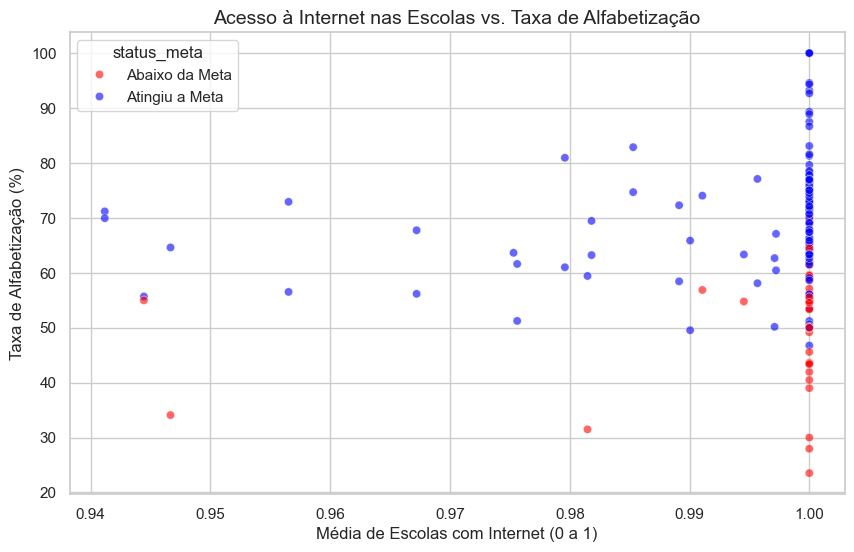

In [3]:
plt.figure()
sns.scatterplot(
    data=df_eda, 
    x='IN_INTERNET', 
    y='taxa_alfabetizacao', 
    hue='status_meta', 
    alpha=0.6, 
    palette={'Acima da Meta': 'green', 'Atingiu a Meta': 'blue', 'Abaixo da Meta': 'red'}
)
plt.title("Acesso à Internet nas Escolas vs. Taxa de Alfabetização", fontsize=14)
plt.xlabel("Média de Escolas com Internet (0 a 1)", fontsize=12)
plt.ylabel("Taxa de Alfabetização (%)", fontsize=12)
plt.show()

> ### 💡 Interpretação do Gráfico: Conectividade vs. Desempenho Educacional
> 
> * **Concentração de Conectividade:** A grande maioria dos municípios analisados apresenta alta média de escolas com acesso à internet (valores concentrados próximos a `1.00`).
> * **Dispersão de Desempenho:** Mesmo em municípios onde a conectividade escolar é de 100%, observa-se uma grande variação na taxa de alfabetização, oscilando de **30% até 100%**.
> * **Status da Meta:** O fato de haver municípios com internet total que ficaram **Abaixo da Meta** (pontos vermelhos) indica que a infraestrutura de tecnologia, embora seja um insumo essencial, **não garante por si só o sucesso educacional**.
> * **Conclusão de Negócio:** Ter internet é uma condição necessária, mas não suficiente. Isso sinaliza para os gestores que intervenções em tecnologia precisam vir acompanhadas de suporte pedagógico e infraestrutura básica.

### Pergunta 2: A vulnerabilidade social atua como uma barreira educacional?
Nossa segunda hipótese é que o ambiente socioeconômico da família influencia diretamente os resultados. Analisaremos a correlação entre famílias vulneráveis (sem ensino fundamental) e o sucesso escolar.

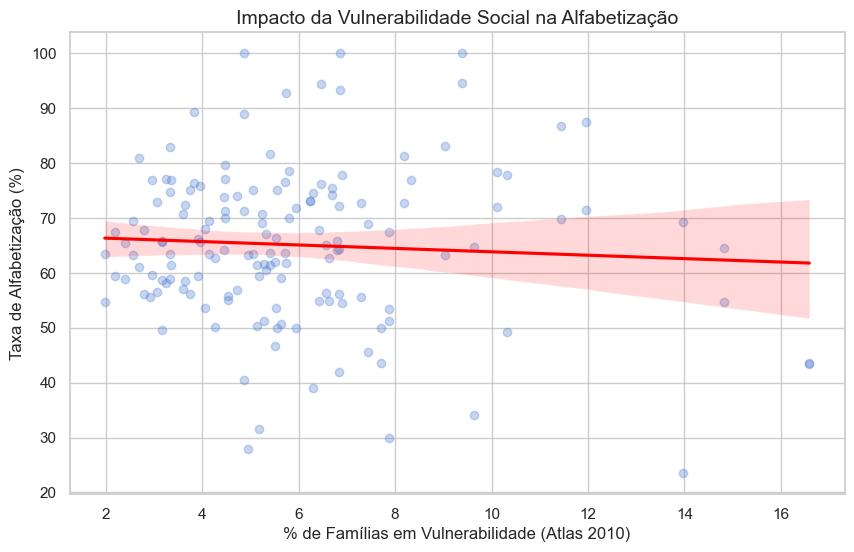

In [5]:
col_vuln = '% de pessoas em domicílios vulneráveis à pobreza e em que ninguém tem ensino fundamental completo 2010'

plt.figure()
sns.regplot(
    data=df_eda, 
    x=col_vuln, 
    y='taxa_alfabetizacao', 
    scatter_kws={'alpha':0.3}, 
    line_kws={'color':'red'}
)
plt.title("Impacto da Vulnerabilidade Social na Alfabetização", fontsize=14)
plt.xlabel("% de Famílias em Vulnerabilidade (Atlas 2010)", fontsize=12)
plt.ylabel("Taxa de Alfabetização (%)", fontsize=12)
plt.show()

> ### 💡 Interpretação do Gráfico: Impacto da Vulnerabilidade Social
> 
> * **Linha de Tendência Negativa:** A reta de regressão em vermelho apresenta uma inclinação descendente. À medida que o percentual de famílias em vulnerabilidade social aumenta no município, a taxa média de alfabetização tende a cair.
> * **Variabilidade Externa:** O sombreado vermelho (intervalo de confiança) se alarga nos extremos devido à menor quantidade de municípios em faixas de altíssima vulnerabilidade (acima de 12%), mas a tendência geral de desvantagem permanece nítida.
> * **Desigualdade de Oportunidade:** Municípios com baixos índices de vulnerabilidade (entre 2% e 6%) concentram as maiores taxas de alfabetização (acima de 70%), enquanto municípios vulneráveis frequentemente registram taxas inferiores a 50%.
> * **Conclusão de Negócio:** O ambiente socioeconômico fora da escola é uma barreira real. O modelo de Machine Learning precisa considerar esses indicadores para não penalizar gestores que atuam em regiões de alta vulnerabilidade social.

### Pergunta 3: Qual a correlação linear entre essas variáveis?
**Insight Crucial:** Ao plotarmos a matriz de correlação, notaremos que os valores individuais (água, internet, vulnerabilidade) apresentam baixa correlação *linear* direta com a taxa de alfabetização. 

Isso não significa que os dados são ruins. Pelo contrário: comprova que a alfabetização é um **problema multifatorial e complexo**. A falta de água sozinha pode não zerar o desempenho, mas a *combinação* de vulnerabilidade social com falta de infraestrutura é crítica. Isso justifica a utilização de modelos de Machine Learning (como Random Forest) na próxima etapa, pois eles conseguem capturar essas interações não-lineares.

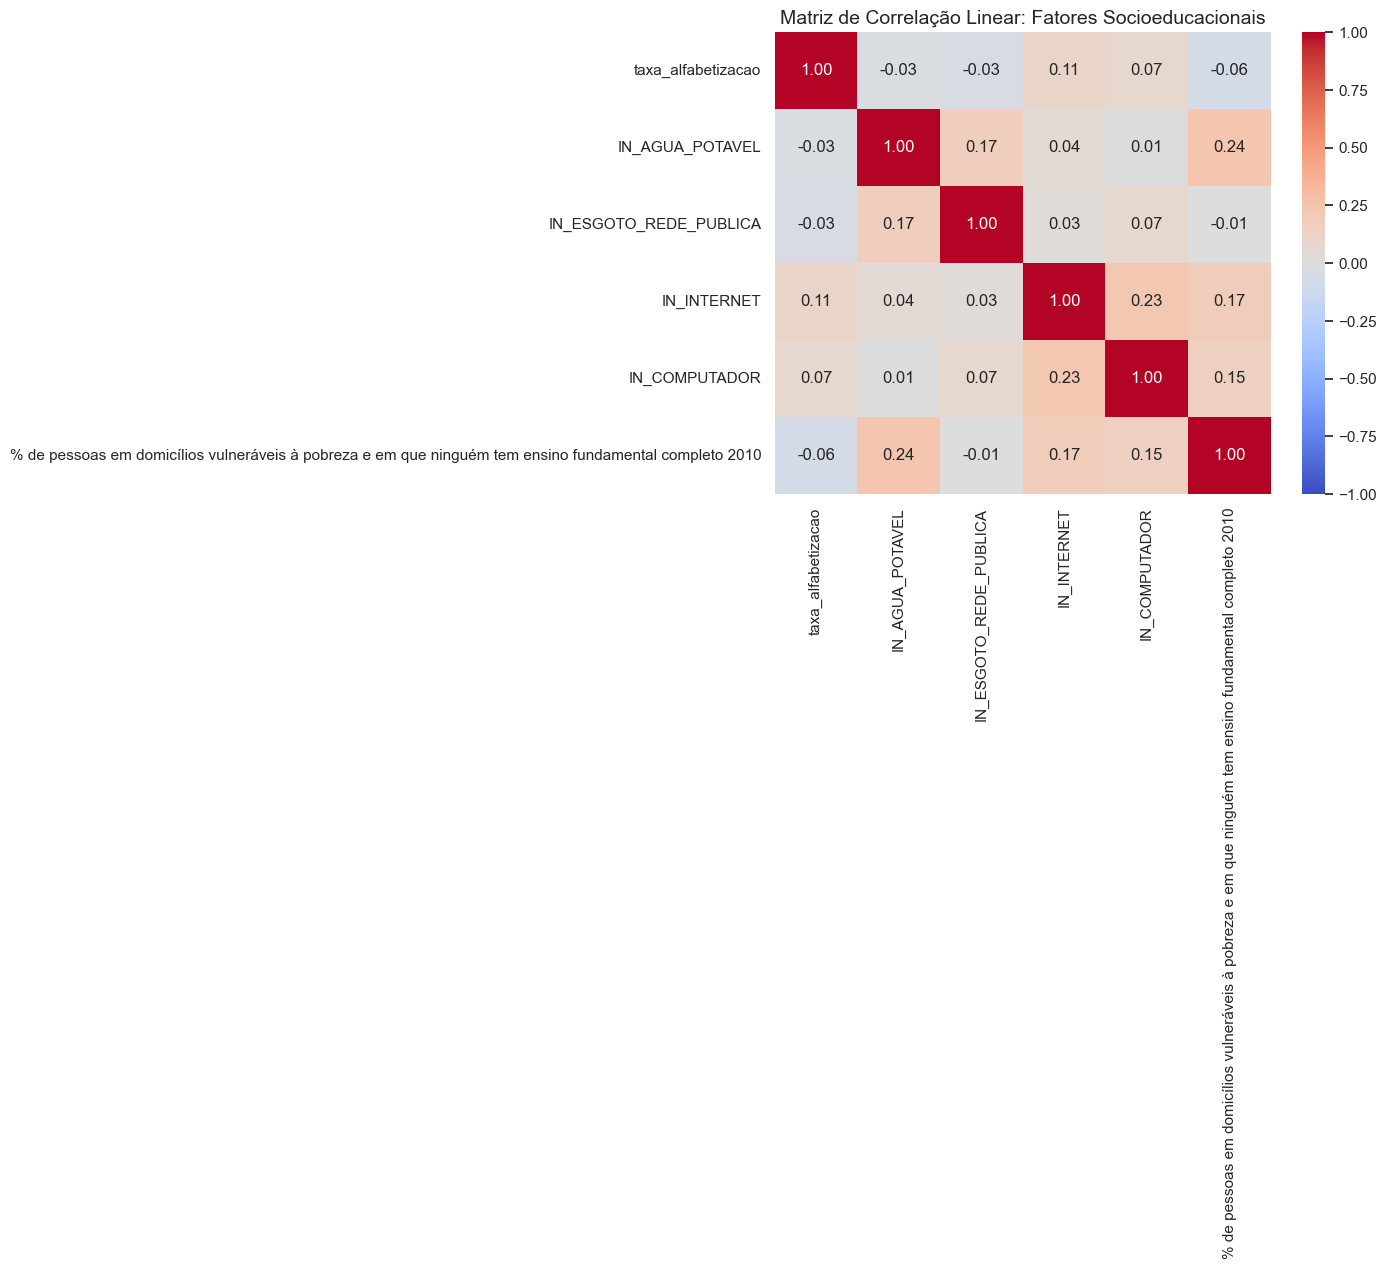

In [6]:
cols_corr = ['taxa_alfabetizacao', 'IN_AGUA_POTAVEL', 'IN_ESGOTO_REDE_PUBLICA', 
             'IN_INTERNET', 'IN_COMPUTADOR', col_vuln]
corr = df_eda[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação Linear: Fatores Socioeducacionais", fontsize=14)
plt.show()

> ### 💡 Interpretação do Gráfico: Matriz de Correlação Linear
> 
> * **Baixas Correlações Diretas:** A variável `taxa_alfabetizacao` apresenta fraca correlação linear isolada com os fatores analisados, oscilando entre **-0.06** (vulnerabilidade) e **0.11** (acesso à internet).
> * **Relações Inter-Infraestrutura:** Notam-se correlações moderadas entre variáveis de infraestrutura e ambiente, como entre `IN_AGUA_POTAVEL` e a variável de vulnerabilidade do Atlas (**0.24**), e entre `IN_INTERNET` e `IN_COMPUTADOR` (**0.23**).
> * **Justificativa do Modelo de Machine Learning:** A ausência de uma forte correlação linear direta **comprova matematicamente que a alfabetização é um fenômeno multifatorial e não-linear**. A falta de água ou de internet isoladamente não destrói o indicador, mas a *combinação* de fatores socioeconômicos desfavoráveis sim.
> * **Conclusão Técnica:** Essa estrutura de dados justifica plenamente o abandono de modelos lineares simples em prol de algoritmos baseados em árvores de decisão (como **Random Forest**), capazes de capturar interações complexas entre múltiplos fatores.

## 3. Exportação da Base Final
Com as hipóteses validadas e a necessidade de um algoritmo complexo justificada pela matriz de correlação, exportaremos a tabela analítica completa (sem os *drops* da EDA) para o pipeline de Machine Learning.

In [7]:
df_master.to_parquet("abt_alfabetizacao_modelagem.parquet")
print("Tabela Analítica salva com sucesso! Prontos para o Notebook 04.")

Tabela Analítica salva com sucesso! Prontos para o Notebook 04.
